### Results

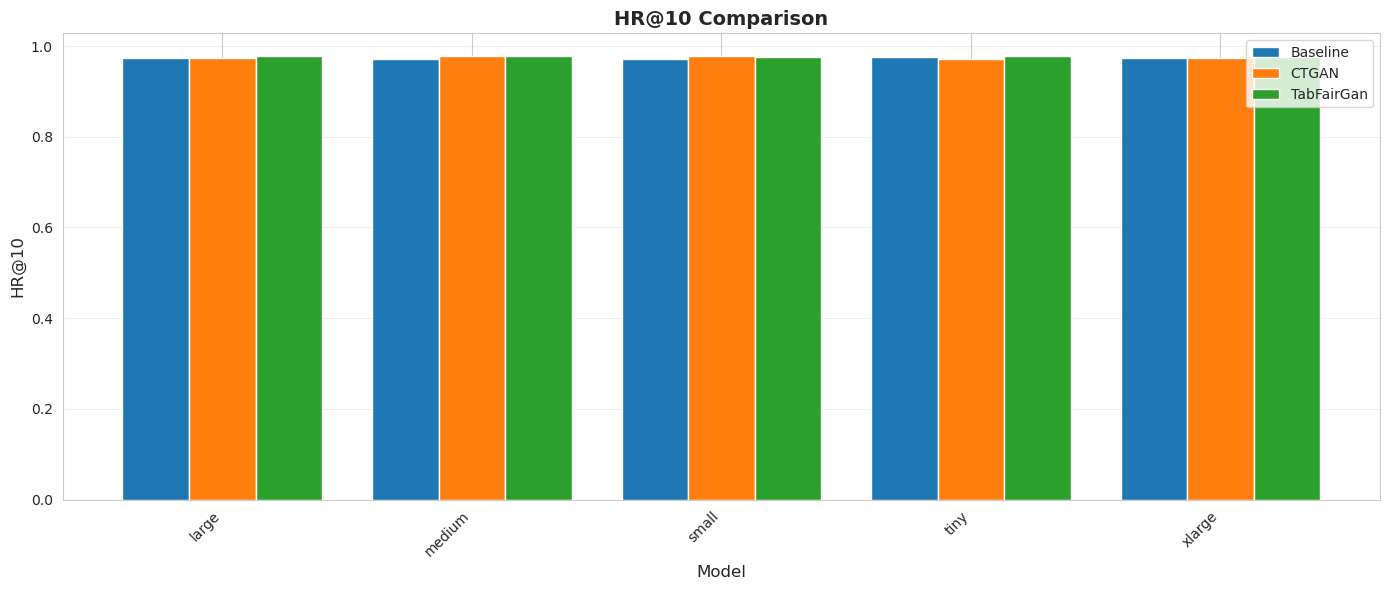

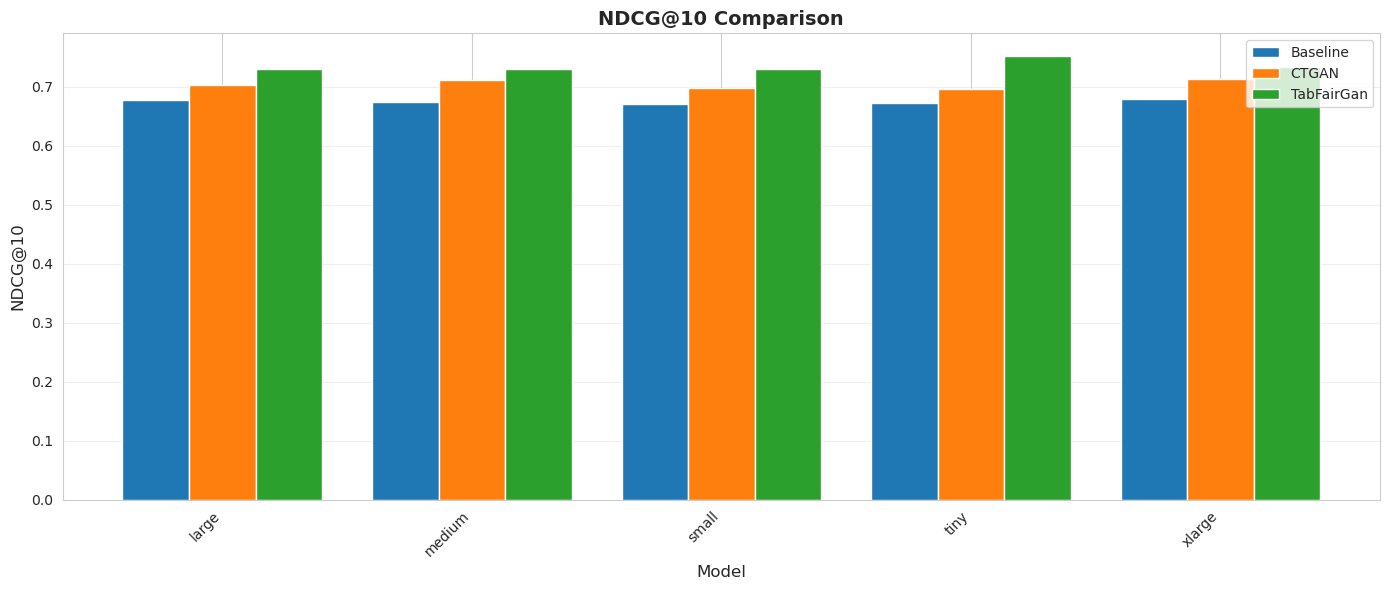

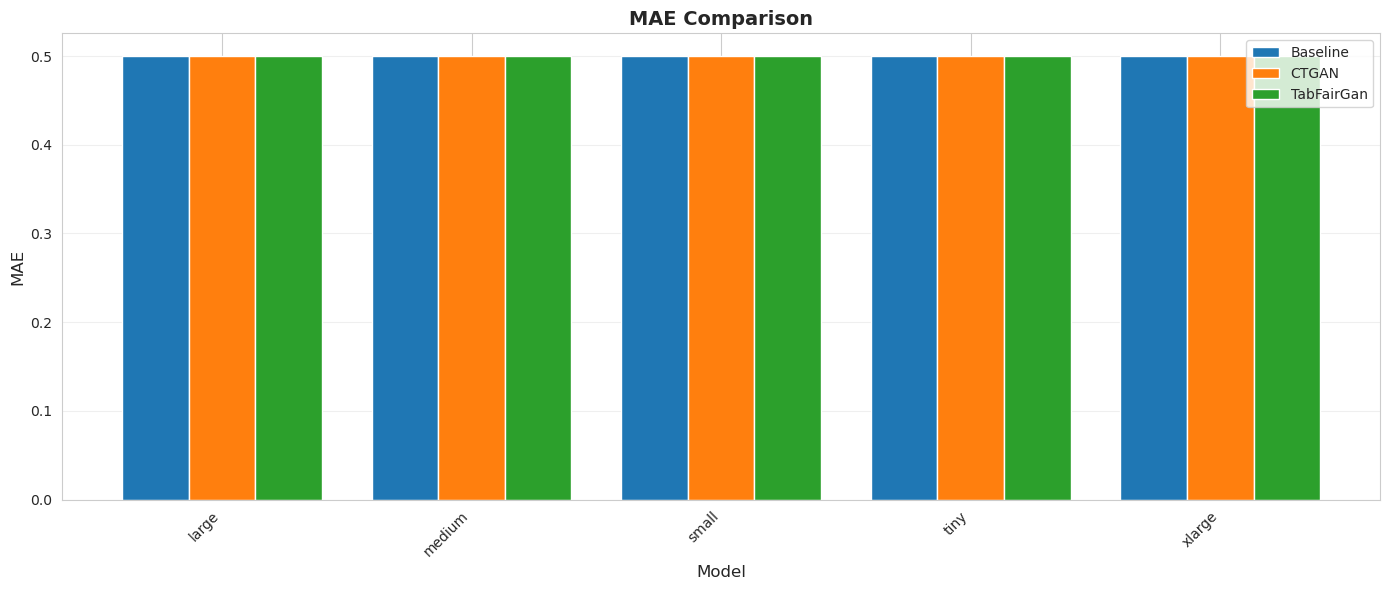

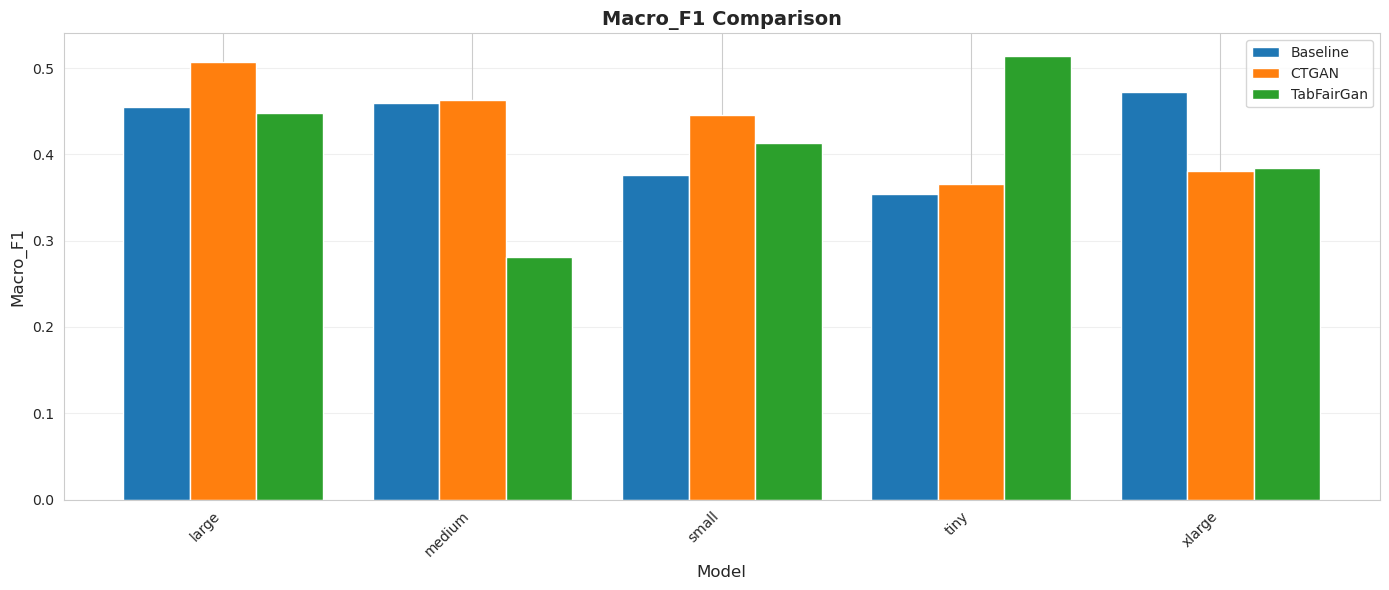

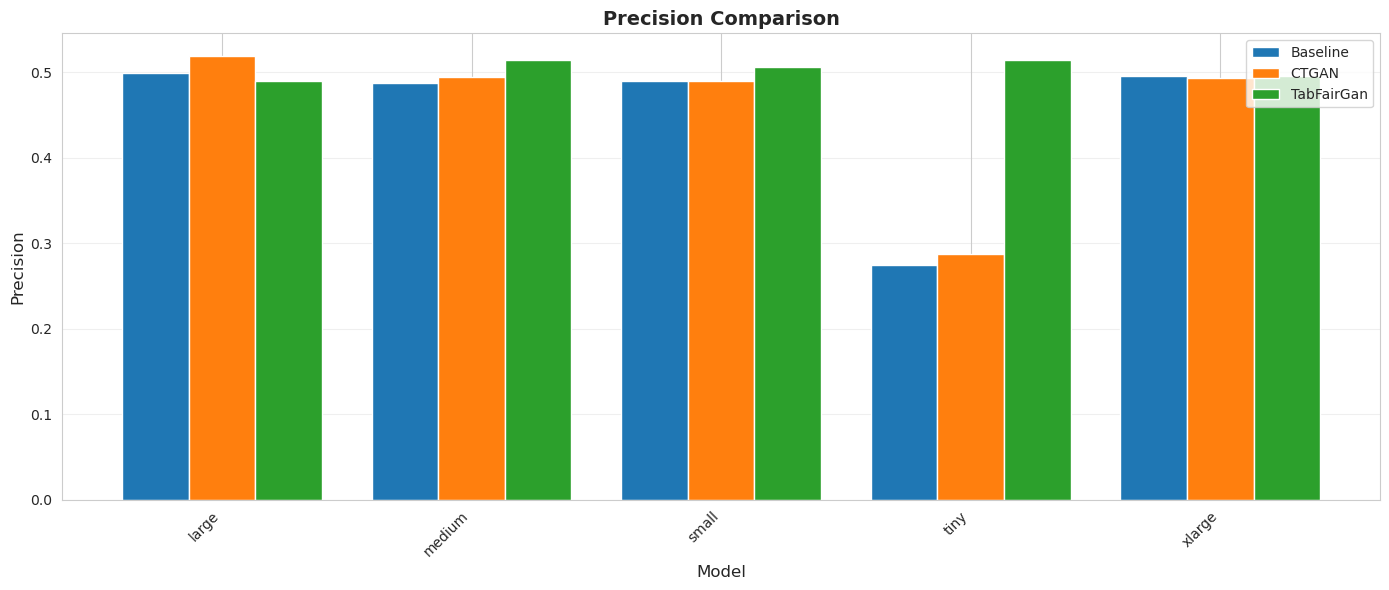

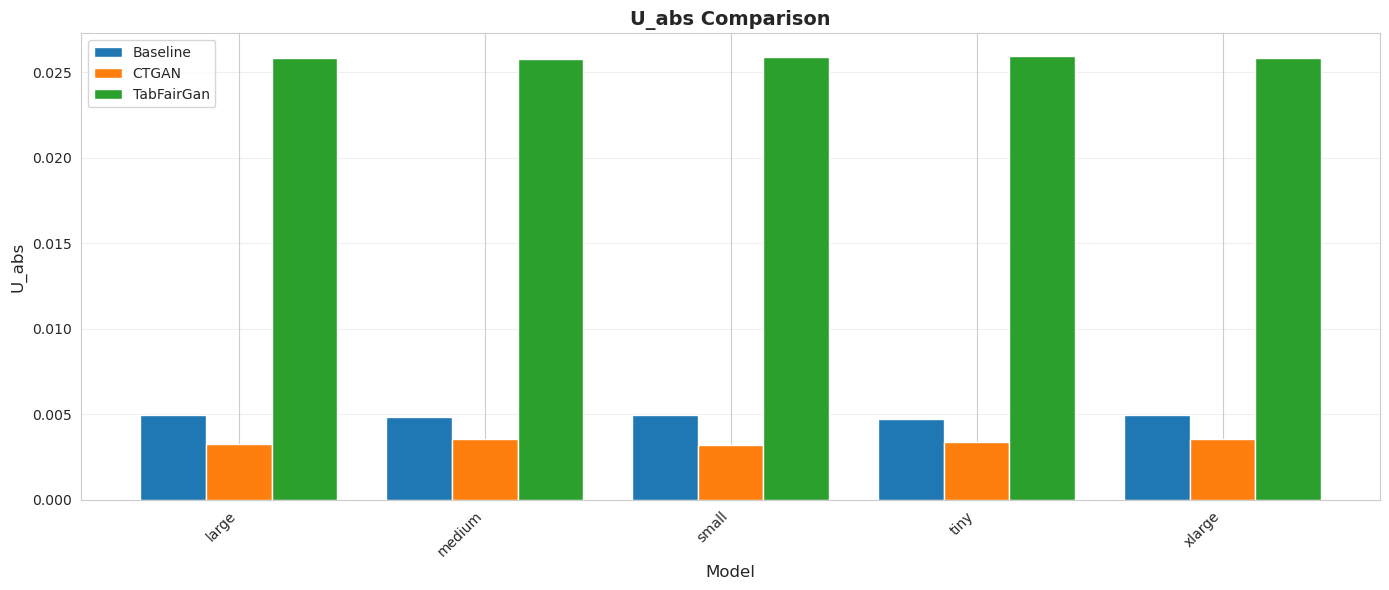


Baseline


,Model,Layers,CNT,TI,MAED,U_abs,HR@10,NDCG@10,MAE,Macro_F1,Precision
0,large,"[32, 16, 8, 4]",1.0,8.729022e-07,0.000035,0.004974,0.974441,0.677273,0.499937,0.455133,0.498939
1,medium,"[16, 8, 4]",1.0,3.035692e-06,0.000090,0.004849,0.972311,0.674510,0.500114,0.459111,0.487131
2,small,"[8, 4]",1.0,3.415325e-06,0.000010,0.004949,0.971246,0.670884,0.500143,0.376062,0.490170
3,tiny,"[4, 2]",1.0,1.146710e-05,0.000226,0.004713,0.975506,0.672804,0.499729,0.354622,0.274740
4,xlarge,"[64, 32, 16, 8]",1.0,1.208734e-06,0.000033,0.004972,0.974441,0.678930,0.499960,0.472031,0.495744



CTGAN


,Model,Layers,CNT,TI,MAED,U_abs,HR@10,NDCG@10,MAE,Macro_F1,Precision
0,large,"[32, 16, 8, 4]",1.000000,0.000002,0.000160,0.003228,0.97417,0.702685,0.499976,0.507039,0.519659
1,medium,"[16, 8, 4]",1.000000,0.000002,0.000144,0.003532,0.97786,0.711119,0.500084,0.462554,0.494077
2,small,"[8, 4]",0.999999,0.000007,0.000213,0.003174,0.97786,0.698631,0.500255,0.445611,0.489683
3,tiny,"[4, 2]",1.000000,0.000006,0.000011,0.003376,0.97048,0.696838,0.499752,0.365285,0.287755
4,xlarge,"[64, 32, 16, 8]",1.000000,0.000001,0.000169,0.003556,0.97417,0.713672,0.500120,0.380736,0.493196



TabFairGan


,Model,Layers,CNT,TI,MAED,U_abs,HR@10,NDCG@10,MAE,Macro_F1,Precision
0,large,"[32, 16, 8, 4]",1.000000,0.000001,0.000046,0.025863,0.978992,0.730123,0.500136,0.448455,0.489653
1,medium,"[16, 8, 4]",0.999999,0.000005,0.000103,0.025806,0.978992,0.730851,0.500610,0.281376,0.513855
2,small,"[8, 4]",0.999999,0.000005,0.000017,0.025926,0.974790,0.729836,0.500327,0.412941,0.505967
3,tiny,"[4, 2]",0.999999,0.000004,0.000082,0.025991,0.978992,0.753307,0.499960,0.514604,0.515011
4,xlarge,"[64, 32, 16, 8]",1.000000,0.000001,0.000081,0.025828,0.974790,0.733558,0.500159,0.384545,0.495358


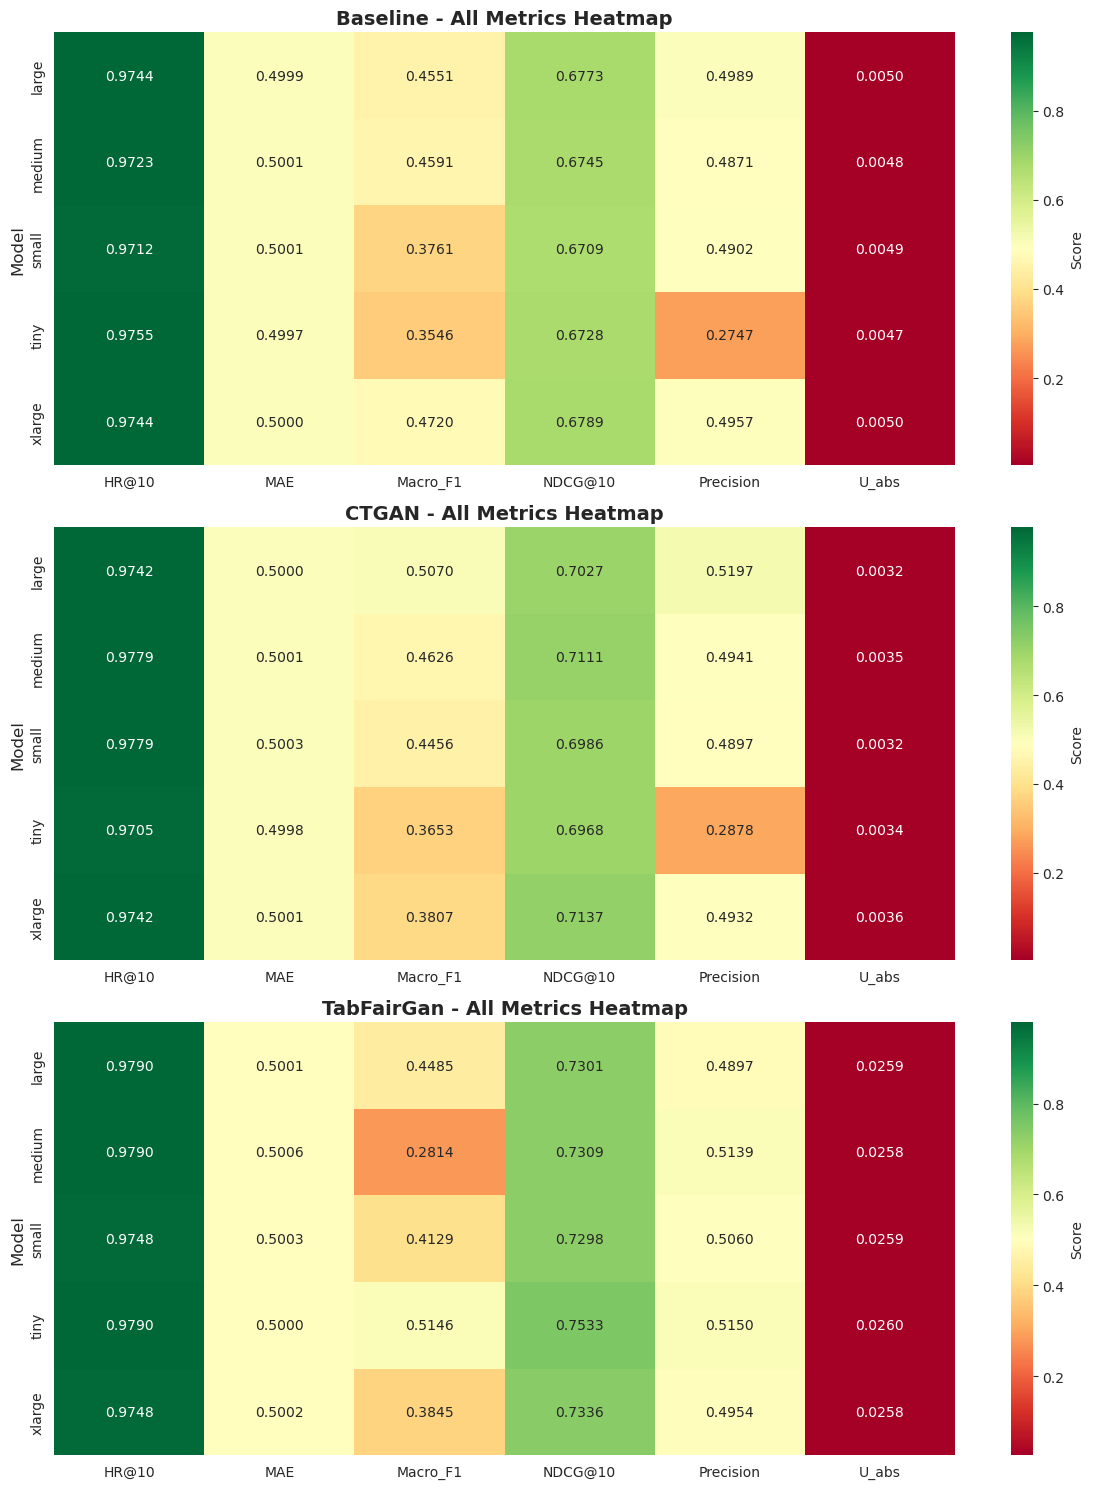

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

files = {
    'Baseline' : 'results/baseline/ml-100k/results.csv',
    'CTGAN'    : 'results/ctgan/ml-100k/results.csv',
    'TabFairGan'    : 'results/tabfairgan/ml-100k/results.csv',
}

dfs = {name: pd.read_csv(path) for name, path in files.items()}

sns.set_style("whitegrid")

metrics = ['HR@10', 'NDCG@10', 'MAE', 'Macro_F1', 'Precision', 'U_abs']

for metric in metrics:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    models = dfs[list(dfs.keys())[0]]['Model']
    x = range(len(models))
    width = 0.8 / len(dfs)
    
    for idx, (name, df) in enumerate(dfs.items()):
        offset = width * idx - (width * (len(dfs) - 1) / 2)
        ax.bar([i + offset for i in x], df[metric], width, label=name)
    
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

for name, df in dfs.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    display(df)

fig, axes = plt.subplots(len(dfs), 1, figsize=(12, 5*len(dfs)))
if len(dfs) == 1:
    axes = [axes]

for idx, (name, df) in enumerate(dfs.items()):
    ax = axes[idx]
    
    df_melted = df.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')
    
    pivot_table = df_melted.pivot(index='Model', columns='Metric', values='Score')
    
    sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax, cbar_kws={'label': 'Score'})
    ax.set_title(f'{name} - All Metrics Heatmap', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.show()